In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix


In [119]:
df=pd.read_csv("Live.csv")

In [120]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   object 
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(9), object(3)
memory 

In [121]:
df.count()

status_id           7050
status_type         7050
status_published    7050
num_reactions       7050
num_comments        7050
num_shares          7050
num_likes           7050
num_loves           7050
num_wows            7050
num_hahas           7050
num_sads            7050
num_angrys          7050
Column1                0
Column2                0
Column3                0
Column4                0
dtype: int64

In [122]:
df = df.drop(['Column1','Column2','Column3','Column4'],axis=1)

In [123]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   status_id         7050 non-null   object
 1   status_type       7050 non-null   object
 2   status_published  7050 non-null   object
 3   num_reactions     7050 non-null   int64 
 4   num_comments      7050 non-null   int64 
 5   num_shares        7050 non-null   int64 
 6   num_likes         7050 non-null   int64 
 7   num_loves         7050 non-null   int64 
 8   num_wows          7050 non-null   int64 
 9   num_hahas         7050 non-null   int64 
 10  num_sads          7050 non-null   int64 
 11  num_angrys        7050 non-null   int64 
dtypes: int64(9), object(3)
memory usage: 661.1+ KB


In [124]:
df.count()

status_id           7050
status_type         7050
status_published    7050
num_reactions       7050
num_comments        7050
num_shares          7050
num_likes           7050
num_loves           7050
num_wows            7050
num_hahas           7050
num_sads            7050
num_angrys          7050
dtype: int64

In [125]:
df['status_type'].unique()


array(['video', 'photo', 'link', 'status'], dtype=object)

In [126]:
len(df['status_type'].unique())

4

In [127]:
df = df.drop(['status_id','status_published','status_type'],axis=1)

In [128]:
df=pd.read_csv("Live.csv")

In [129]:
df = df.drop(['Column1','Column2','Column3','Column4','status_id','status_published'],axis=1)

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   status_type    7050 non-null   object
 1   num_reactions  7050 non-null   int64 
 2   num_comments   7050 non-null   int64 
 3   num_shares     7050 non-null   int64 
 4   num_likes      7050 non-null   int64 
 5   num_loves      7050 non-null   int64 
 6   num_wows       7050 non-null   int64 
 7   num_hahas      7050 non-null   int64 
 8   num_sads       7050 non-null   int64 
 9   num_angrys     7050 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 550.9+ KB


DECLARE FEATURE VECTOR AND TARGET VARIABLE

In [131]:
x=df
y=df['status_type']
type(x)

pandas.core.frame.DataFrame

convert categorial variable into integers

In [132]:
from sklearn.preprocessing import LabelEncoder


In [133]:
le = LabelEncoder()
x['status_type'] = le.fit_transform(x['status_type'])


In [134]:
import numpy as np

In [135]:
le = LabelEncoder()
y = le.fit_transform(y)

In [136]:
cols= x.columns

In [137]:
from sklearn.preprocessing import MinMaxScaler

In [138]:
ms=MinMaxScaler()

In [139]:
x=ms.fit_transform(x)

In [140]:
x=pd.DataFrame(x, columns=[cols])

In [141]:
x.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1.000000,0.112314,0.024393,0.076519,0.091720,0.140030,0.010791,0.006369,0.019608,0.0
1,0.333333,0.031847,0.000000,0.000000,0.031847,0.000000,0.000000,0.000000,0.000000,0.0
2,1.000000,0.048195,0.011243,0.016647,0.043312,0.031963,0.003597,0.006369,0.000000,0.0
3,0.333333,0.023567,0.000000,0.000000,0.023567,0.000000,0.000000,0.000000,0.000000,0.0
4,0.333333,0.045223,0.000000,0.000000,0.043312,0.013699,0.000000,0.000000,0.000000,0.0


In [142]:
from sklearn.cluster import KMeans
KMeans = KMeans(n_clusters=2,random_state=0)


In [143]:
KMeans.fit(x)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


CENTER CLUSTER

In [144]:
KMeans.cluster_centers_

array([[9.54921576e-01, 6.46330441e-02, 2.67028654e-02, 2.93171709e-02,
        5.71231462e-02, 4.71007076e-02, 8.18581889e-03, 9.65207685e-03,
        8.04219428e-03, 7.19501847e-03],
       [3.28506857e-01, 3.90710874e-02, 7.54854864e-04, 7.53667113e-04,
        3.85438884e-02, 2.17448568e-03, 2.43721364e-03, 1.20039760e-03,
        2.75348016e-03, 1.45313276e-03]])

INERTIA

In [145]:
KMeans.inertia_

237.75726404419547

In [146]:
labels = KMeans.labels_

correct_labels = sum(y == labels)


In [147]:
print("Result: %d out of %d samples were correctly labelled,"%(correct_labels,y.size))

Result: 4288 out of 7050 samples were correctly labelled,


In [148]:
print('Accuracy Score: {0:0.2f}'.format(correct_labels/float(y.size)))

Accuracy Score: 0.61


In [149]:
from sklearn.cluster import KMeans
# cs=[]
# for i in range(1,11):
#     kmeans= KMeans(n_clusters=i, init = 'K-means++', max_iter=300,n_init=10,random_state=0)
#     kmeans.fit(x)
#     cs.append(kmeans.inertia_)

# x = np.random.rand(100, 2) 
x=pd.DataFrame(x, columns=[cols])
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(x)
    cs.append(kmeans.inertia_)

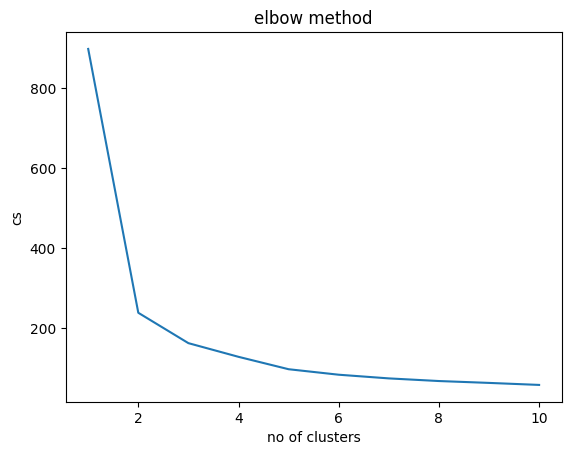

In [150]:
plt.plot(range(1,11),cs)
plt.title("elbow method")
plt.xlabel("no of clusters")
plt.ylabel('cs')
plt.show()